<a href="https://colab.research.google.com/github/Rifath-Mahmud/CVPR/blob/main/catdog_cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [48]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


In [49]:
import kagglehub
path = kagglehub.dataset_download("tongpython/cat-and-dog")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'cat-and-dog' dataset.
Path to dataset files: /kaggle/input/cat-and-dog


In [50]:
import torchvision.transforms as transforms
train_transform = transforms.Compose([
    transforms.Resize((64, 64)),        # resize to model input size
    transforms.RandomHorizontalFlip(),    # horizontal flip augmentation
    transforms.RandomRotation(15),        # rotate ±15 degrees
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor()                # convert PIL → tensor [0,1]
])

val_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
])

train_folder = '/kaggle/input/cat-and-dog/test_set/test_set'
test_folder = '/kaggle/input/cat-and-dog/test_set/test_set'

train_data = datasets.ImageFolder(train_folder,transform = train_transform)
test_data = datasets.ImageFolder(test_folder,transform = val_transform)

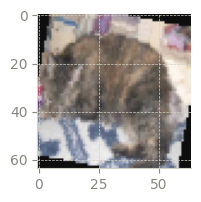

In [51]:
plt.figure(figsize = (2,2))
plt.imshow(train_data[800][0].permute(1,2,0))

In [52]:
#important HyperParameters
batch_size = 32
learning_rate=0.001
minimum_learning_rate=1e-4
epochs = 30

In [53]:
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True,num_workers=4, pin_memory=True)
val_loader = DataLoader(test_data, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [54]:
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR

def get_model():
  model = nn.Sequential(
            nn.Conv2d(3,64,kernel_size=3),
            nn.MaxPool2d(2),
            nn.ReLU(),
            nn.Conv2d(64,128,kernel_size=3),
            nn.MaxPool2d(2),
            nn.ReLU(),
            nn.Conv2d(128,128,kernel_size=3),
            nn.MaxPool2d(2),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(128*6*6,256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256,2)
            )
  return model.to(device)

#1. Get the Model
model = get_model()
# 2. Define optimizer
optimizer = Adam(model.parameters(), lr=learning_rate)
# 3. Define LR scheduler
scheduler = CosineAnnealingLR(optimizer, T_max=epochs, eta_min=minimum_learning_rate)
# 4. Define loss function
criterion = nn.CrossEntropyLoss()

from torchsummary import summary
summary(model, input_size=(3,64,64));

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 62, 62]           1,792
         MaxPool2d-2           [-1, 64, 31, 31]               0
              ReLU-3           [-1, 64, 31, 31]               0
            Conv2d-4          [-1, 128, 29, 29]          73,856
         MaxPool2d-5          [-1, 128, 14, 14]               0
              ReLU-6          [-1, 128, 14, 14]               0
            Conv2d-7          [-1, 128, 12, 12]         147,584
         MaxPool2d-8            [-1, 128, 6, 6]               0
              ReLU-9            [-1, 128, 6, 6]               0
          Flatten-10                 [-1, 4608]               0
           Linear-11                  [-1, 256]       1,179,904
             ReLU-12                  [-1, 256]               0
          Dropout-13                  [-1, 256]               0
           Linear-14                   

In [55]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        total_loss += loss.item()

        # compute accuracy
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = total_loss / len(loader)
    train_acc = correct / total

    return train_loss, train_acc

def validate_epoch(model, loader, criterion, device):

    model.eval()

    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_loss = total_loss / len(loader)
    val_acc = correct / total

    return val_loss, val_acc

In [56]:
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

for epoch in range(epochs):
    print(f"----------------------------------------------------")
    print(f"Epoch {epoch+1}/{epochs}, LR: {optimizer.param_groups[0]['lr']:.6g}")

    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = validate_epoch(model, val_loader, criterion, device)
    scheduler.step()

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

----------------------------------------------------
Epoch 1/30, LR: 0.001


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Train Loss: 0.6953 | Train Acc: 0.5067
Val Loss: 0.6926 | Val Acc: 0.5190
----------------------------------------------------
Epoch 2/30, LR: 0.001
Train Loss: 0.6923 | Train Acc: 0.5121
Val Loss: 0.6908 | Val Acc: 0.5299
----------------------------------------------------
Epoch 3/30, LR: 0.001
Train Loss: 0.6925 | Train Acc: 0.5230
Val Loss: 0.6918 | Val Acc: 0.5166
----------------------------------------------------
Epoch 4/30, LR: 0.001
Train Loss: 0.6897 | Train Acc: 0.5269
Val Loss: 0.6825 | Val Acc: 0.5744
----------------------------------------------------
Epoch 5/30, LR: 0.001
Train Loss: 0.6868 | Train Acc: 0.5586
Val Loss: 0.6798 | Val Acc: 0.5373
----------------------------------------------------
Epoch 6/30, LR: 0.001
Train Loss: 0.6783 | Train Acc: 0.5734
Val Loss: 0.6683 | Val Acc: 0.5729
----------------------------------------------------
Epoch 7/30, LR: 0.001
Train Loss: 0.6693 | Train Acc: 0.5877
Val Loss: 0.6541 | Val Acc: 0.6293
--------------------------------

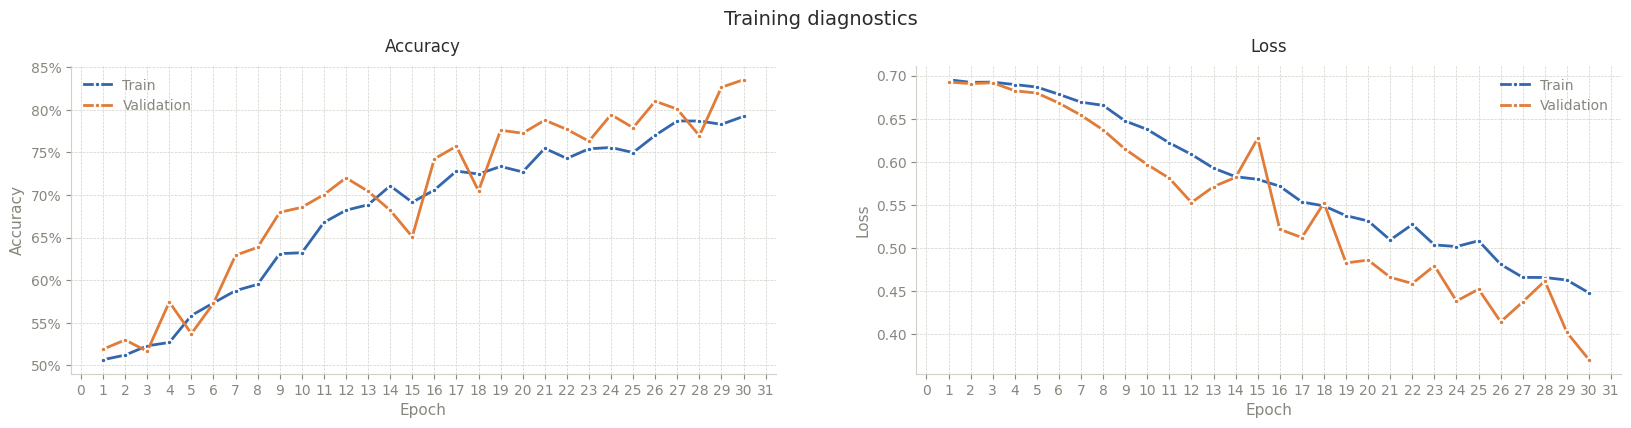

In [57]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
import numpy as np

BLUE   = "#3266ad"
ORANGE = "#e07b39"
GRAY   = "#88877f"

plt.rcParams.update({
    "font.family": "sans-serif",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": "#d3d1c7",
    "axes.linewidth": 0.8,
    "axes.grid": True,
    "grid.color": "#d3d1c7",
    "grid.linewidth": 0.5,
    "grid.linestyle": "--",
    "xtick.color": GRAY,
    "ytick.color": GRAY,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

epochs_number = np.arange(1, epochs + 1)
fig = plt.figure(figsize=(20, 4))
gs  = gridspec.GridSpec(1, 2, figure=fig, wspace=0.2)

# ── Accuracy ──────────────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0])
ax1.plot(epochs_number, train_accuracies, color=BLUE,   lw=2,   label="Train",      marker="o", ms=4, mew=1.5, mec="white")
ax1.plot(epochs_number, val_accuracies,   color=ORANGE, lw=2,   label="Validation", marker="o", ms=4, mew=1.5, mec="white", linestyle="-")
ax1.xaxis.set_major_locator(mticker.MultipleLocator(1))
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x*100:.0f}%"))
ax1.set_xlabel("Epoch", color=GRAY, fontsize=11)
ax1.set_ylabel("Accuracy", color=GRAY, fontsize=11)
ax1.set_title("Accuracy", fontsize=12, fontweight="medium", color="#2c2c2a", pad=10)
ax1.legend(frameon=False, fontsize=10, labelcolor=GRAY)

# ── Loss ──────────────────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1])
ax2.plot(epochs_number, train_losses, color=BLUE,   lw=2, label="Train",      marker="o", ms=4, mew=1.5, mec="white")
ax2.plot(epochs_number, val_losses,   color=ORANGE, lw=2, label="Validation", marker="o", ms=4, mew=1.5, mec="white", linestyle="-")
ax2.xaxis.set_major_locator(mticker.MultipleLocator(1))
ax2.yaxis.set_major_locator(mticker.MultipleLocator(0.05))
ax2.set_xlabel("Epoch", color=GRAY, fontsize=11)
ax2.set_ylabel("Loss",  color=GRAY, fontsize=11)
ax2.set_title("Loss", fontsize=12, fontweight="medium", color="#2c2c2a", pad=10)
ax2.legend(frameon=False, fontsize=10, labelcolor=GRAY)

fig.suptitle("Training diagnostics", fontsize=14, fontweight="medium", color="#2c2c2a", y=1.02)
plt.savefig("training_curves.pdf", bbox_inches="tight", dpi=150)
plt.show()

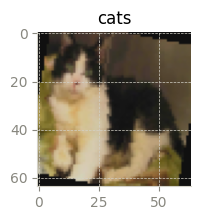

In [79]:
ix = torch.randint(0,1000,())
img = train_data[ix][0].unsqueeze(0).to(device)
np_output = model(img).cpu().detach().numpy()
pred = np.exp(np_output)/np.sum(np.exp(np_output))
plt.figure(figsize=(2,2))
plt.imshow(img.squeeze(0).permute(1,2,0).cpu().detach().numpy())
plt.title(train_data.classes[pred[0].argmax()])
plt.show()

In [65]:
train_data[ix][0].shape

torch.Size([3, 64, 64])